In [1]:
import pandas as pd
import git
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dfs = {}
for file in Path("new_TF2_data").glob("*.txt"):
    df = pd.read_csv(file, index_col=0, parse_dates=[0])
    df = df.rename_axis(index="time")
    df["DOTm"] /= 100
    df.name = "run_" + "".join([c for c in file.name if c.isdigit()])
    dfs[df.name] = df

df

,Biomass,Substrate,Acetate,DOTm,Product,Volume,Feed
time,,,,,,,
2021-06-28 09:41:57,NaN,NaN,NaN,NaN,NaN,0.010000,0.000000
2021-06-28 09:51:16,NaN,NaN,NaN,0.993158,NaN,NaN,0.000000
2021-06-28 09:52:27,NaN,NaN,NaN,0.995835,NaN,NaN,0.000000
2021-06-28 09:53:38,NaN,NaN,NaN,0.997132,NaN,NaN,0.000000
2021-06-28 09:54:49,NaN,NaN,NaN,0.991703,NaN,NaN,0.000000
...,...,...,...,...,...,...,...
2021-06-28 20:55:01,NaN,NaN,NaN,0.624043,NaN,NaN,0.000000
2021-06-28 21:01:57,NaN,NaN,NaN,NaN,NaN,0.009432,0.000021
2021-06-28 21:11:57,NaN,NaN,NaN,NaN,NaN,NaN,0.000021


In [3]:
import matplotlib.dates as mdates

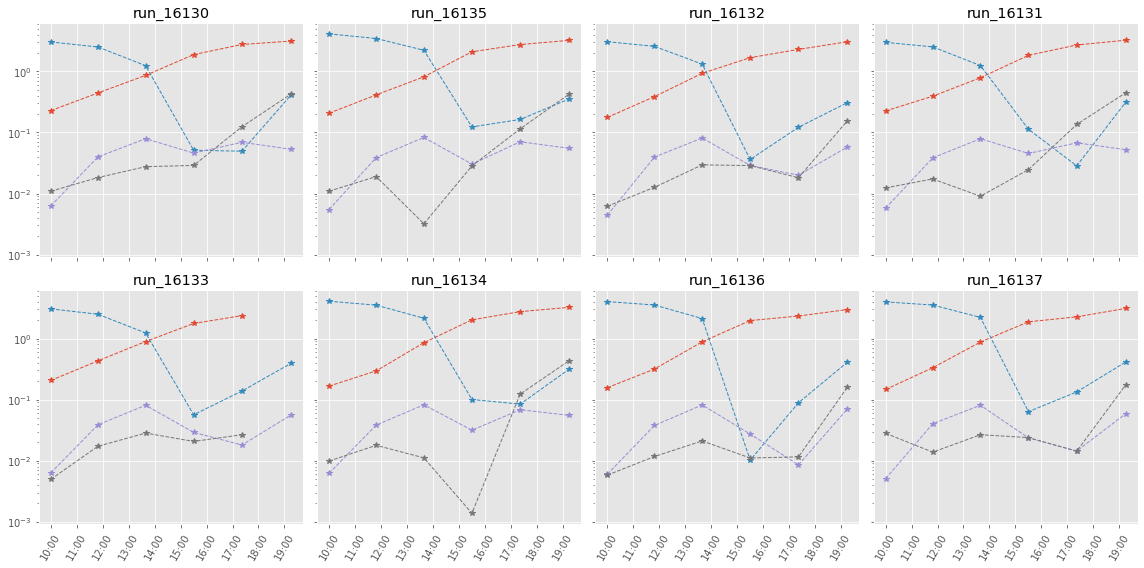

In [4]:
plt.style.use("ggplot")
fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(16, 8),
    sharex=True,
    sharey=True,
    tight_layout=True,
    subplot_kw={"yscale": "log"},
)

for df, ax in zip(dfs.values(), axes.flatten()):
    x = df.index
    for col in df.columns:
        if col in ("Biomass", "Substrate", "Acetate", "Product"):
            y = df[col]
            mask = pd.notna(y)
            (line,) = ax.plot(x[mask], y[mask], ls="--", lw=1, marker="*")
            ax.plot(x, y, color=line.get_color(), lw=1.5)
    ax.set_title(df.name)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params("x", labelrotation=60)

In [5]:
import os

if os.path.exists("in_silico_data.h5"):
    os.remove("in_silico_data.h5")

for df in dfs.values():
    df.to_hdf("in_silico_data.h5", key=df.name, mode="a")

In [6]:
import h5py
import pandas as pd

with h5py.File("in_silico_data.h5", "r") as file:
    read_dfs = {}
    for key in file.keys():
        read_dfs[key] = pd.read_hdf("in_silico_data.h5", key=key)

In [7]:
for key in dfs:
    pd.testing.assert_frame_equal(dfs[key], read_dfs[key])

In [8]:
read_dfs["run_16130"]

,Biomass,Substrate,Acetate,DOTm,Product,Volume,Feed
time,,,,,,,
2021-06-28 09:41:57,NaN,NaN,NaN,NaN,NaN,0.010000,0.000000
2021-06-28 09:53:38,NaN,NaN,NaN,0.983902,NaN,NaN,0.000000
2021-06-28 09:54:49,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000
2021-06-28 09:55:59,NaN,NaN,NaN,0.986402,NaN,NaN,0.000000
2021-06-28 09:57:10,NaN,NaN,NaN,0.974205,NaN,NaN,0.000000
...,...,...,...,...,...,...,...
2021-06-28 20:55:01,NaN,NaN,NaN,0.651887,NaN,NaN,0.000000
2021-06-28 21:01:57,NaN,NaN,NaN,NaN,NaN,0.009797,0.000022
2021-06-28 21:11:57,NaN,NaN,NaN,NaN,NaN,0.009810,0.000022


In [10]:
tables = list(dfs.values())

for col in tables[0].columns:
    print(f">>> {col} <<<")
    for df in tables:
        print(df[col].min(), df[col].max())

>>> Biomass <<<
0.2274755271214943 3.131119466289237
0.2066821607501609 3.2214423249773865
0.1761781075138258 3.0567487814692904
0.2254177659133089 3.2361306202700977
0.2062277617630636 2.3758679324240437
0.1666271288542588 3.2427817665185064
0.1568614318292293 2.9843809574535625
0.1468522562241366 3.117234525201792
>>> Substrate <<<
0.0492638468819067 3.0323019288233706
0.1231900796279477 4.1143144086635175
0.0360761005661157 3.060281680730013
0.0283309084308233 2.9825782001914405
0.0565277818959557 3.0644747715788867
0.0844908101284657 4.084674532040829
0.0102257504238314 4.033477663415
0.0635003592713655 3.98660648071304
>>> Acetate <<<
0.0062602452279495 0.0789858165452404
0.00546762570377 0.0828181458010214
0.004422172691864 0.0811377395161097
0.005774770689658 0.0789957702555892
0.0062986062013099 0.0809071226070051
0.0062270272137445 0.0823396552488212
0.0060138715518277 0.081862100137273
0.0050910057668892 0.080888388850759
>>> DOTm <<<
0.3345661133934587 1.0
0.3477504855991411